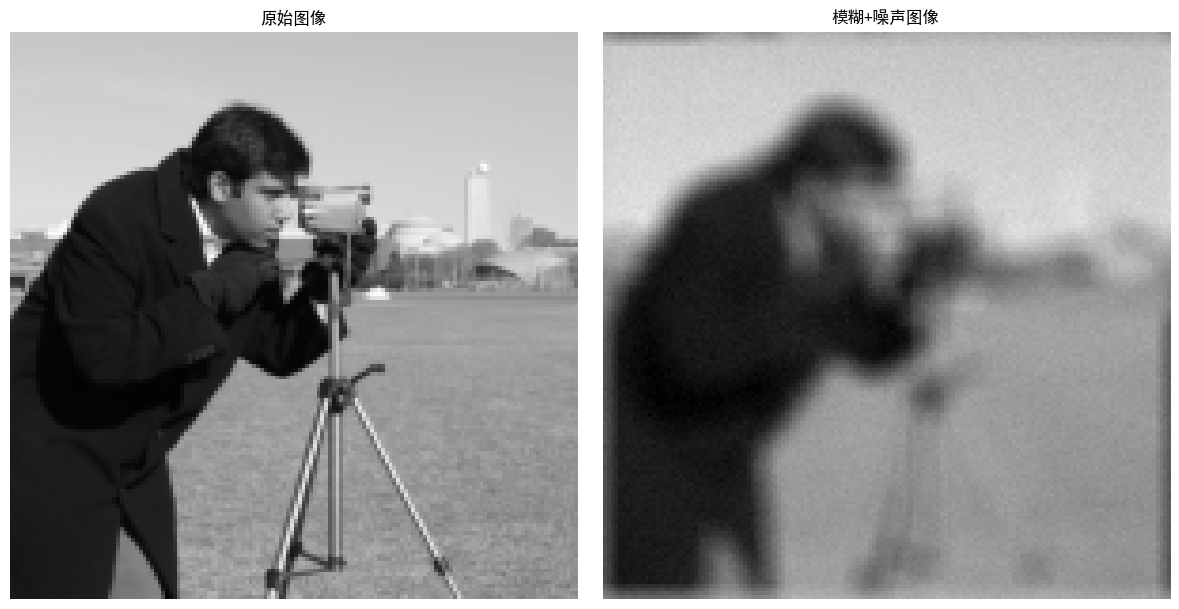

ULA参数（取自 lab1_ULA_sol）:
  lambda=30, epsilon=0.01, L=34000.0, delta=1/L=0.000029
  n_iter=20000, burn_in=2000


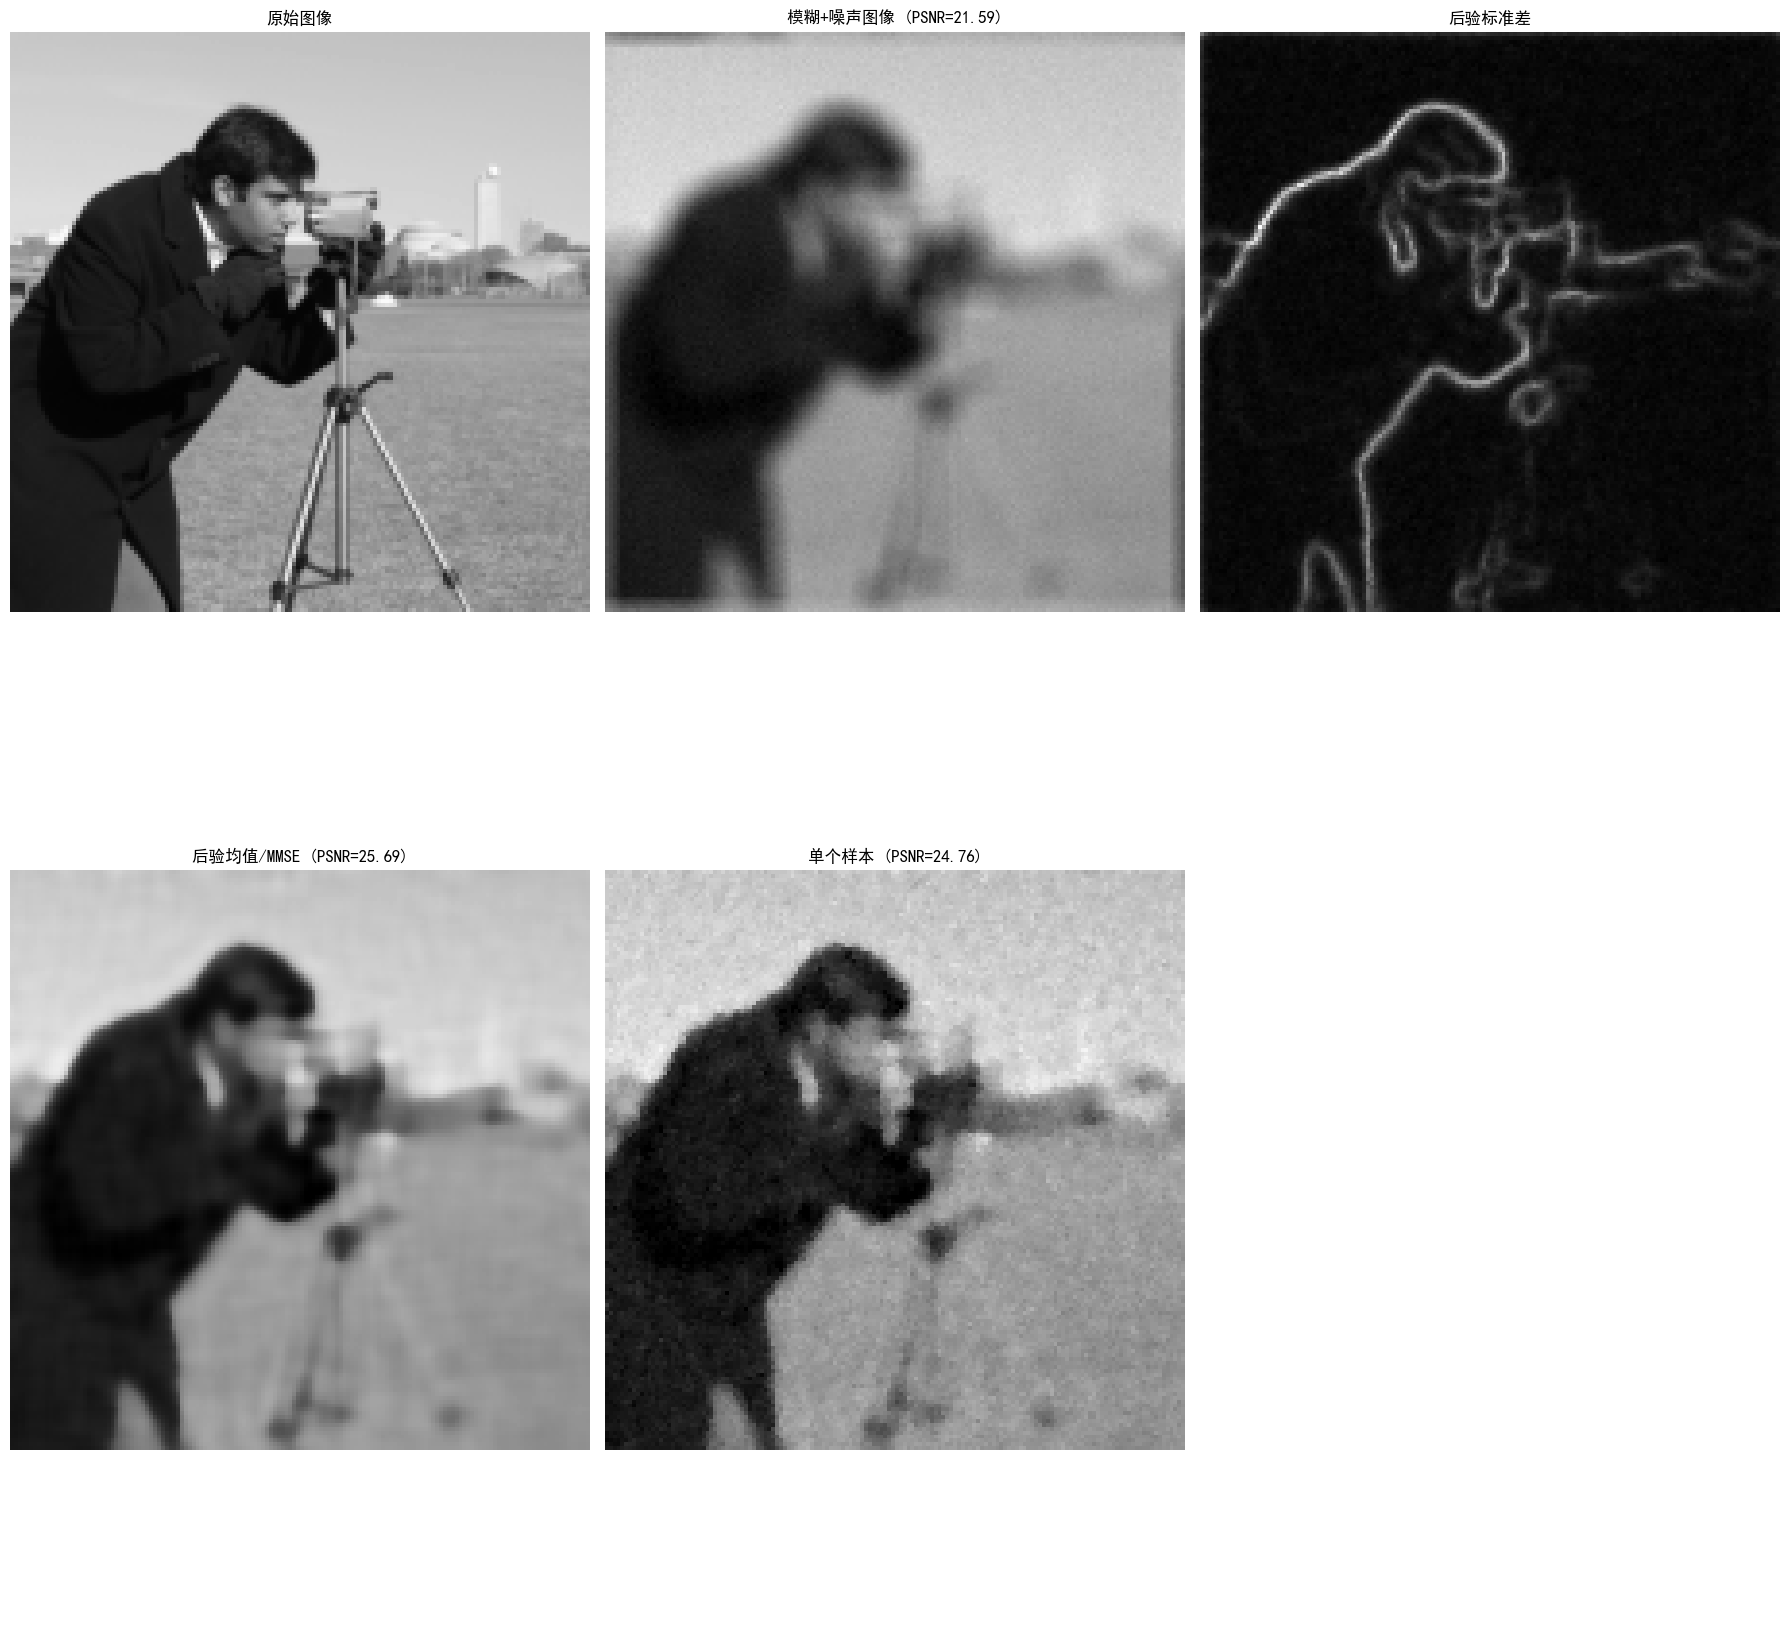

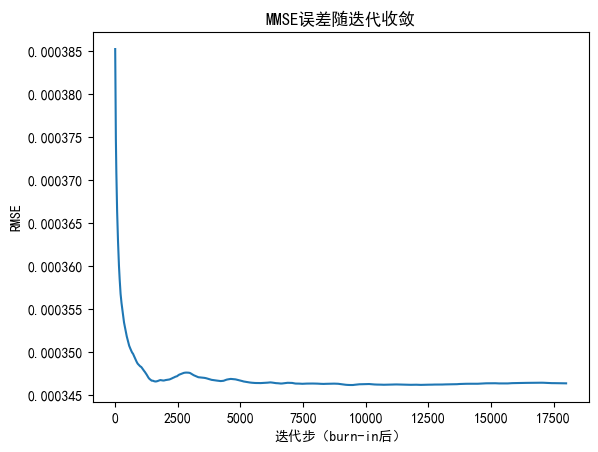

In [4]:
"""
实验4.3 2D图像ULA后验采样（去卷积）
对应章节：4.3/4.4（高维ULA、Huber-TV近似、后验均值/方差、MMSE）
素材来源：Mathematics.../Teaching Unit 2/labs/lab1_ULA_sol.ipynb
  - Cell 6: kernel() / convol_periodic()
  - Cell 8: grad() / div()
  - Cell 9: grad_htv() / ula_deblurring()
  - Cell 10: PSNR()
  - Cell 7: 图像加载与模糊噪声参数
  - Cell 11: ULA参数
  - Cell 12-13: 可视化
  注：图像加载原代码用wget下载simpson_nb512.png，此处改用skimage内置图像
"""

import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import warnings
import logging
from skimage.data import camera
from skimage.transform import resize

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ============================================================
# 辅助函数（逐字取自 lab1_ULA_sol.ipynb Cell 6,8,9,10）
# ============================================================

# --- Cell 6 ---
def kernel(n_row, n_col, s):
   # kernel definition (for (2*s+1, 2*s+1) uniform kernel)
   h = np.zeros((n_row,n_col))
   h[0:s+1,0:s+1] = np.ones((s+1, s+1))/(2*s+1)**2
   h[0:s+1,-s:] = np.ones((s+1, s))/(2*s+1)**2
   h[-s:,0:s+1] = np.ones((s, s+1))/(2*s+1)**2
   h[-s:,-s:] = np.ones((s, s))/(2*s+1)**2
   return h

def convol_periodic(a,b):
   return np.real(np.fft.ifft2(np.fft.fft2(a)*np.fft.fft2(b)))

# --- Cell 8 ---
def grad(im):
    """
    computes the gradient of the image 'im'
    """

    nr,nc=im.shape

    gx = im[:,1:]-im[:,0:-1]
    gx = np.block([gx,np.zeros((nr,1))])

    gy =im[1:,:]-im[0:-1,:]
    gy=np.block([[gy],[np.zeros((1,nc))]])
    return gx,gy

def div(cx,cy):
    """
    cy and cy are coordonates of a vector field.
    #the function computes the discrete divergence of this vector field
    """

    nr,nc=cx.shape

    ddx=np.zeros((nr,nc))
    ddy=np.zeros((nr,nc))

    ddx[:,1:-1]=cx[:,1:-1]-cx[:,0:-2]
    ddx[:,0]=cx[:,0]
    ddx[:,-1]=-cx[:,-2]

    ddy[1:-1,:]=cy[1:-1,:]-cy[0:-2,:]
    ddy[0,:]=cy[0,:]
    ddy[-1,:]=-cy[-2,:]

    d=ddx+ddy

    return d

# --- Cell 9 ---
def grad_htv(I, eps):
    """
    This function allows to compute the gradient of the HTV energy of an image.
    Inputs:
        - I: the image
        - eps (int): regularization parameter
    """
    grad_x, grad_y = grad(I)
    norme = np.sqrt(grad_x**2 + grad_y**2)
    temp1 = -1/(eps)*div(grad_x,grad_y)
    temp2 = (-div(grad_x/(norme+1e-15), grad_y/(norme+1e-15)))
    return  temp1*(norme < eps) + temp2*(norme>=eps)


def ula_deblurring(im_blurred, im_orig, sigma, delta, lambd, epsilon, h, inter= 10, n_iter = 10000, n_burn_in = 1000):
    """
    Inputs:
        - im_blurred: noisy image
        - im_orig: original image (to compute output MMSE_error)
        - sigma: standard deviation of noise of noisy image.
        - delta: parameter of ULA iteration
        - lambd: TV regularization parameter lambd
        - epsilon: Regularization for HTV (since ULA needs differentiable potentials)
        - h: kernel of convolution
        - inter: Interval to save samples
        - n_iter: Total number of iterations
        - n_burn_in: Number of iterations for the burn-in phase.
    Outputs:
        - X_mean: The average posterior
        - Xf: Last sample
        - std: The posterior std
        - X_samples: sequence of samples through iterations
        - MMSE_error: Average error between X_mean and u
    """

    # Initializations
    n_Rows, n_Col = im_blurred.shape
    samples = np.zeros((n_Rows, n_Col,int(n_iter/inter)))
    X_mean = np.copy(im_blurred)
    X_2 = np.zeros((n_Rows, n_Col))
    MMSE_error = []
    X = np.zeros((n_Rows, n_Col)) # Markov chain initialization

    # Conjugate of the kernel h
    h_fft = np.fft.fft2(h)
    hc_fft = np.conj(h_fft)
    hc = np.fft.ifft2(hc_fft)

    for i in range(n_iter):
        # Gradient of the potential
        Z = np.random.randn(n_Rows, n_Col)
        ATA_x = np.real(np.fft.ifft2((hc_fft*h_fft)*np.fft.fft2(X)))
        AT_y = np.real(np.fft.ifft2(hc_fft*np.fft.fft2(im_blurred)))
        grad = (ATA_x- AT_y)/sigma**2 + lambd*grad_htv(X,epsilon)

        # ULA step
        X = X - delta*grad + np.sqrt(2*delta)*Z

        # Keep samples
        if (i%inter==0):
            samples[:,:,int(i/inter)] = np.copy(X)

        # Compute mean of X, and mean of X**2
        if i>=n_burn_in:
            i_b = i - n_burn_in#
            X_mean = i_b/(i_b+1)*X_mean + 1/(i_b+1)*X
            X_2 = i_b/(i_b+1)*X_2 + 1/(i_b+1)*(X**2)
            MMSE_error = MMSE_error + [1/(n_Rows*n_Col)*np.sqrt(np.sum((X_mean - im_orig)**2))]

    # Variance computation
    var = X_2 - X_mean**2
    std = np.sqrt(var*(var>=0))

    return X_mean, X, std, samples, MMSE_error,

# --- Cell 10 ---
def PSNR(im_0, im_rest):
    """
    This function allows to compute the PSNR.
    Inputs:
        -im_0: the original image
        -im_rest: the restored image
    Output:
        -the PSNR
    """
    N = im_0.shape[0]
    M = im_0.shape[1]
    EQM = np.linalg.norm(im_0 - im_rest, 'fro')**2/N/M

    return -10*math.log10(EQM)


# ============================================================
# 准备图像（原代码 Cell 7 用wget下载simpson_nb512.png，改用skimage内置）
# ============================================================
u = camera().astype(float) / 255.0
u = resize(u, (150, 150), anti_aliasing=True)

# blurred image + noise （参数取自 Cell 7）
sigma = 0.01
h = kernel(u.shape[0], u.shape[1], 4)
ub = convol_periodic(u,h) + sigma*np.random.randn(u.shape[0],u.shape[1])

# 显示原图与模糊图（取自 Cell 7 的显示代码）
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes[0].set_title('原始图像')
axes[0].imshow(u,cmap='gray',vmin=0,vmax=1)
axes[0].axis('off')
axes[1].set_title('模糊+噪声图像')
axes[1].imshow(ub,cmap='gray',vmin=0,vmax=1)
axes[1].axis('off')
fig.tight_layout()
plt.show()

# ============================================================
# ULA参数（取自 Cell 11）
# ============================================================
lambd = 30
epsilon = .01
L = 1/sigma**2 + 8*lambd/epsilon # Lipschitz constant
delta = 1/L # step-size
inter = 10 # interval between samples that are kept in the file X_samples
n_iter = int(2e4)
n_burn_in = int(0.1*n_iter)

print(f"ULA参数（取自 lab1_ULA_sol）:")
print(f"  lambda={lambd}, epsilon={epsilon}, L={L:.1f}, delta=1/L={delta:.6f}")
print(f"  n_iter={n_iter}, burn_in={n_burn_in}")

# ============================================================
# 运行ULA（取自 Cell 11）
# ============================================================
X_mean, Xf, std, X_samples, MMSE_error = ula_deblurring(ub, u, sigma, delta, lambd, epsilon, h, inter, n_iter, n_burn_in)

# ============================================================
# 可视化（取自 Cell 12-13 的显示代码）
# ============================================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 18))
axes[0][0].set_title('原始图像')
axes[0][0].imshow(u,cmap='gray',vmin=0,vmax=1)
axes[0][0].axis('off')
axes[0][1].set_title('模糊+噪声图像 (PSNR={:.2f})'.format(PSNR(u, ub)))
axes[0][1].imshow(ub,cmap='gray',vmin=0,vmax=1)
axes[0][1].axis('off')
axes[0][2].set_title('后验标准差')
axes[0][2].imshow(std,cmap='gray')
axes[0][2].axis('off')
axes[1][0].set_title('后验均值/MMSE (PSNR={:.2f})'.format(PSNR(u, X_mean)))
axes[1][0].imshow(X_mean,cmap='gray',vmin=0,vmax=1)
axes[1][0].axis('off')
axes[1][1].set_title('单个样本 (PSNR={:.2f})'.format(PSNR(u, Xf)))
axes[1][1].imshow(Xf,cmap='gray',vmin=0,vmax=1)
axes[1][1].axis('off')
axes[1][2].axis('off')
fig.tight_layout()
plt.show()

plt.plot(MMSE_error)
plt.title('MMSE误差随迭代收敛')
plt.xlabel('迭代步（burn-in后）')
plt.ylabel('RMSE')
plt.show()
